In [1]:
import torch
import numpy as np
from pathlib import Path
import os

In [2]:
# check working dir
print(f"current working directory: {os.getcwd()}\n")

ckpt_dir = Path("../results/STree_Debug/ckpts")
if ckpt_dir.exists():
    print(f"find file: {ckpt_dir.absolute()}")
    print(f"\nfiles in directory:")
    for f in sorted(ckpt_dir.glob("*.pt")):
        size_mb = f.stat().st_size / (1024**2)
        print(f"  - {f.name:40s} ({size_mb:.1f} MB)")
else:
    print(f"directory does not exist: {ckpt_dir.absolute()}")
    # try to find correct path
    possible_paths = [
        Path("results/STree_Debug/ckpts"),
        Path("../results/STree_Debug/ckpts"),
        Path("/home/jonas/Code/gsplat/results/STree_Debug/ckpts"),
    ]
    for p in possible_paths:
        if p.exists():
            print(f"\nfind correct path: {p.absolute()}")
            break

current working directory: /home/jonas/Code/ObjectRemoval4GS/gsplat/examples

find file: /home/jonas/Code/ObjectRemoval4GS/gsplat/examples/../results/STree_Debug/ckpts

files in directory:
  - ckpt_14999_rank0.pt                      (518.4 MB)
  - ckpt_6999_rank0.pt                       (518.4 MB)


In [3]:
ckpt_initial = torch.load("../results/STree2/ckpts/ckpt_29999_rank0.pt", map_location="cpu")
splats_initial = ckpt_initial["splats"]
print(f"initial splats parameters (each gaussian ellipsoid):")
print("-" * 80)
for key, value in sorted(splats_initial.items()):
    if isinstance(value, torch.Tensor):
        print(f"  {key:20s}: shape={str(value.shape):25s} dtype={str(value.dtype):15s}")
    else:
        print(f"  {key:20s}: {type(value)}")

initial splats parameters (each gaussian ellipsoid):
--------------------------------------------------------------------------------
  means               : shape=torch.Size([2265128, 3])  dtype=torch.float32  
  opacities           : shape=torch.Size([2265128])     dtype=torch.float32  
  quats               : shape=torch.Size([2265128, 4])  dtype=torch.float32  
  scales              : shape=torch.Size([2265128, 3])  dtype=torch.float32  
  sh0                 : shape=torch.Size([2265128, 1, 3]) dtype=torch.float32  
  shN                 : shape=torch.Size([2265128, 15, 3]) dtype=torch.float32  


In [7]:
# load checkpoint
ckpt_before = torch.load("../results/STree_Debug/ckpts/ckpt_14999_rank0.pt", map_location="cpu")
ckpt_pruned = torch.load("../results/STree_Debug/ckpts/ckpt_Pruned_04.pt", map_location="cpu")

print("=" * 80)
print("ckpt_4999_rank0.pt (checkpoint after training)")
print("=" * 80)
print(f"\nTop-level keys: {list(ckpt_before.keys())}\n")

splats_before = ckpt_before["splats"]
print(f"Splats parameters (each gaussian ellipsoid):")
print("-" * 80)
for key, value in sorted(splats_before.items()):
    if isinstance(value, torch.Tensor):
        print(f"  {key:20s}: shape={str(value.shape):25s} dtype={str(value.dtype):15s}")
    else:
        print(f"  {key:20s}: {type(value)}")

num_gaussians_before = splats_before["means"].shape[0]
print(f"\n# gaussian ellipsoids: {num_gaussians_before:,}")

print("\n" + "=" * 80)
print("ckpt_pruned_rank0.pt (checkpoint after pruning)")
print("=" * 80)
print(f"\nTop-level keys: {list(ckpt_pruned.keys())}\n")

splats_pruned = ckpt_pruned["splats"]
print(f"Splats parameters (each gaussian ellispoid):")
print("-" * 80)
for key, value in sorted(splats_pruned.items()):
    if isinstance(value, torch.Tensor):
        print(f"  {key:20s}: shape={str(value.shape):25s} dtype={str(value.dtype):15s}")
    else:
        print(f"  {key:20s}: {type(value)}")

num_gaussians_pruned = splats_pruned["means"].shape[0]
print(f"\n# gaussian ellipsoids: {num_gaussians_pruned:,}")

print("\n" + "=" * 80)
print("Comparation:")
print("=" * 80)
print(f"after training: {num_gaussians_before:,} gaussian ellipsoids")
print(f"after pruning:  {num_gaussians_pruned:,} gaussian ellipsoids")
print(f"removing:       {num_gaussians_before - num_gaussians_pruned:,} gaussian ellispoids")
print(f"removal ratio:  {(num_gaussians_before - num_gaussians_pruned) / num_gaussians_before * 100:.2f}%")

ckpt_4999_rank0.pt (checkpoint after training)

Top-level keys: ['step', 'splats']

Splats parameters (each gaussian ellipsoid):
--------------------------------------------------------------------------------
  foreground_logits   : shape=torch.Size([2265128])     dtype=torch.float32  
  means               : shape=torch.Size([2265128, 3])  dtype=torch.float32  
  opacities           : shape=torch.Size([2265128])     dtype=torch.float32  
  quats               : shape=torch.Size([2265128, 4])  dtype=torch.float32  
  scales              : shape=torch.Size([2265128, 3])  dtype=torch.float32  
  sh0                 : shape=torch.Size([2265128, 1, 3]) dtype=torch.float32  
  shN                 : shape=torch.Size([2265128, 15, 3]) dtype=torch.float32  

# gaussian ellipsoids: 2,265,128

ckpt_pruned_rank0.pt (checkpoint after pruning)

Top-level keys: ['step', 'splats']

Splats parameters (each gaussian ellispoid):
--------------------------------------------------------------------------

## parameters for gaussian ellipsoids

each gaussian ellipsoid（Gaussian Splat）has 7 parameters：

1. **`means`** [N, 3]: 3D center position (x, y, z)
2. **`quats`** [N, 4]: rotation（in Quaternion）
3. **`scales`** [N, 3]: scales on each axis（in log format）
4. **`opacities`** [N]: opacity（in logit format）
5. **`sh0`** [N, 1, 3]: spheric harmonics 0 level（base color，RGB）
6. **`shN`** [N, 15, 3]: spheric harmonics 1-3 level（for color changing from muilti-view）
7. **`foreground_logits`** [N]: **probability of in the foreground**（new）

---

### foreground_logits

- **`foreground_logits`**: through `sigmoid(foreground_logits)` get foreground probability [0, 1]
  - P ≈ 1.0：the gaussian ellipsoid belongs to foreground（remove）
  - P ≈ 0.0：the gaussian ellipsoid belongs to background（keep）

distribution of foreground_logits

after training:
  min: 0.0000
  max: 1.0000
  mean: 0.0567
  medium: 0.0001
  std var: 0.1991

after pruning:
  min: 0.0000
  max: 0.3999
  mean: 0.0005
  medium: 0.0001
  std var: 0.0093

remove gaussian ellipsoids:
  nums: 188,138
  probability range: almost >= 0.3 (threshold)


/tmp/ipykernel_1889400/12457387.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_1889400/12457387.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


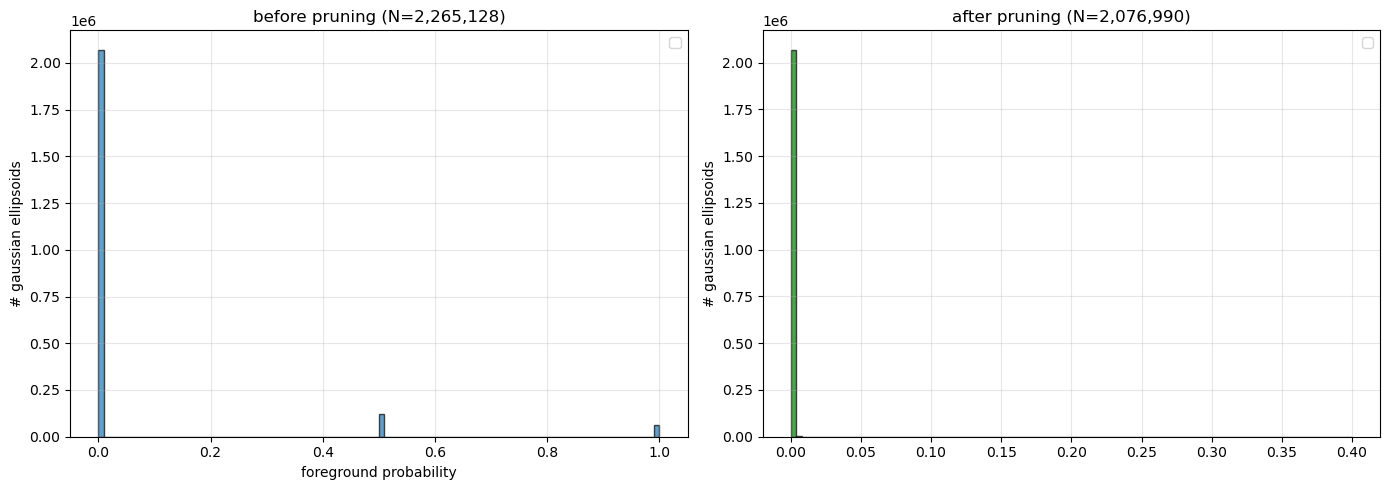


before pruning
  [0.0, 0.1): 2,072,751 (91.51%)
  [0.1, 0.1):    1,274 ( 0.06%)
  [0.1, 0.1):      798 ( 0.04%)
  [0.1, 0.2):      582 ( 0.03%)
  [0.2, 0.2):      503 ( 0.02%)
  [0.2, 0.3):      362 ( 0.02%)
  [0.3, 0.3):      380 ( 0.02%)
  [0.3, 0.4):      340 ( 0.02%)
  [0.4, 0.5):      314 ( 0.01%)
  [0.5, 0.5):      281 ( 0.01%)
  [0.5, 0.6):  119,233 ( 5.26%)
  [0.6, 0.6):      274 ( 0.01%)
  [0.6, 0.7):      296 ( 0.01%)
  [0.7, 0.7):      300 ( 0.01%)
  [0.7, 0.8):      310 ( 0.01%)
  [0.8, 0.8):      332 ( 0.01%)
  [0.8, 0.8):      435 ( 0.02%)
  [0.8, 0.9):      546 ( 0.02%)
  [0.9, 0.9):      884 ( 0.04%)
  [0.9, 1.0):   64,933 ( 2.87%)

after pruning
  [0.0, 0.1): 2,072,751 (99.80%)
  [0.1, 0.1):    1,274 ( 0.06%)
  [0.1, 0.1):      798 ( 0.04%)
  [0.1, 0.2):      582 ( 0.03%)
  [0.2, 0.2):      503 ( 0.02%)
  [0.2, 0.3):      362 ( 0.02%)
  [0.3, 0.3):      380 ( 0.02%)
  [0.3, 0.4):      340 ( 0.02%)
  [0.4, 0.5):        0 ( 0.00%)
  [0.5, 0.5):        0 ( 0.00%)
  [0.5,

In [8]:
import matplotlib.pyplot as plt

# distribution of foreground_logits
fg_logits_before = splats_before["foreground_logits"]
fg_prob_before = torch.sigmoid(fg_logits_before)

fg_logits_pruned = splats_pruned["foreground_logits"]
fg_prob_pruned = torch.sigmoid(fg_logits_pruned)

print("=" * 80)
print("distribution of foreground_logits")
print("=" * 80)

print("\nafter training:")
print(f"  min: {fg_prob_before.min():.4f}")
print(f"  max: {fg_prob_before.max():.4f}")
print(f"  mean: {fg_prob_before.mean():.4f}")
print(f"  medium: {fg_prob_before.median():.4f}")
print(f"  std var: {fg_prob_before.std():.4f}")

print("\nafter pruning:")
print(f"  min: {fg_prob_pruned.min():.4f}")
print(f"  max: {fg_prob_pruned.max():.4f}")
print(f"  mean: {fg_prob_pruned.mean():.4f}")
print(f"  medium: {fg_prob_pruned.median():.4f}")
print(f"  std var: {fg_prob_pruned.std():.4f}")


print("\nremove gaussian ellipsoids:")
print(f"  nums: {num_gaussians_before - num_gaussians_pruned:,}")
print(f"  probability range: almost >= 0.3 (threshold)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before pruning
axes[0].hist(fg_prob_before.numpy(), bins=100, alpha=0.7, edgecolor='black')
# axes[0].axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='threshold = 0.3')
axes[0].set_xlabel('foreground probability')
axes[0].set_ylabel('# gaussian ellipsoids')
axes[0].set_title(f'before pruning (N={num_gaussians_before:,})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# after pruning
axes[1].hist(fg_prob_pruned.numpy(), bins=100, alpha=0.7, color='green', edgecolor='black')
# axes[1].axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='threshold = 0.3')
axes[0].set_xlabel('foreground probability')
axes[1].set_ylabel('# gaussian ellipsoids')
axes[1].set_title(f'after pruning (N={num_gaussians_pruned:,})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# # gaussian ellipsoids in each probability range
print("\n" + "=" * 80)
print("before pruning")
print("=" * 80)
bins = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
for i in range(len(bins)-1):
    mask = (fg_prob_before >= bins[i]) & (fg_prob_before < bins[i+1])
    count = mask.sum().item()
    percentage = count / num_gaussians_before * 100
    print(f"  [{bins[i]:.1f}, {bins[i+1]:.1f}): {count:8,} ({percentage:5.2f}%)")

print("\n" + "=" * 80)
print("after pruning")
print("=" * 80)
bins = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
for i in range(len(bins)-1):
    mask = (fg_prob_pruned >= bins[i]) & (fg_prob_pruned < bins[i+1])
    count = mask.sum().item()
    percentage = count / num_gaussians_pruned * 100
    print(f"  [{bins[i]:.1f}, {bins[i+1]:.1f}): {count:8,} ({percentage:5.2f}%)")

In [10]:
# check training configs
print("=" * 80)
print("check training configs and loss")
print("=" * 80)

# 1. check tensorboard log
tb_dir = Path("../results/Tree_Improved_v1/tb")
if tb_dir.exists():
    print(f"  TensorBoard log found: {tb_dir}")
    print(f"  check training curve:")
    print(f"  tensorboard --logdir {tb_dir.absolute()}")
else:
    print(f"  TensorBoard not found")

# 2. check config files
cfg_file = Path("../results/Tree_Improved_v1/cfg.yml")
if cfg_file.exists():
    print(f"\n  config files found: {cfg_file}")
    try:
        with open(cfg_file, 'r') as f:
            import yaml
            # use unsafe loader to process Python specified objects
            cfg = yaml.load(f, Loader=yaml.UnsafeLoader)
            print(f"\nkey configs:")
            print(f"  - max_steps: {cfg.get('max_steps', 'N/A')}")
            print(f"  - foreground_loss: {cfg.get('foreground_loss', 'N/A')}")
            print(f"  - foreground_lambda: {cfg.get('foreground_lambda', 'N/A')}")
            print(f"  - foreground_lr: {cfg.get('foreground_lr', 'N/A')}")
            print(f"  - foreground_warmup_steps: {cfg.get('foreground_warmup_steps', 'N/A')}")
            print(f"  - freeze_scene_params: {cfg.get('freeze_scene_params', 'N/A')}")
    except Exception as e:
        print(f"\n  failed to read config files: {e}")
        print(f"  read text...")
        with open(cfg_file, 'r') as f:
            lines = f.readlines()
            print(f"\n configs in first 20 rows")
            for i, line in enumerate(lines[:20], 1):
                print(f"  {i:2d}: {line.rstrip()}")
else:
    print(f"\n config files not found")

# 3. analyze foreground distribution
print(f"\n" + "=" * 80)
print("foreground distribution")
print("=" * 80)

prob_high = (fg_prob_before >= 0.8).sum().item()
prob_medium_high = (fg_prob_before >= 0.5).sum().item()
prob_medium = ((fg_prob_before >= 0.3) & (fg_prob_before < 0.7)).sum().item()
prob_low = (fg_prob_before < 0.3).sum().item()

total = fg_prob_before.shape[0]

print(f"\ncurrent distribution")
print(f"  high confidence foreground     [0.8, 1.0): {prob_high:8,} ({prob_high/total*100:5.2f}%)  ← 20-40%")
print(f"  mid-high confidence foreground [0.5, 0.8): {prob_medium_high - prob_high:8,} ({(prob_medium_high-prob_high)/total*100:5.2f}%)")
print(f"  not-sure are                   [0.3, 0.7): {prob_medium:8,} ({prob_medium/total*100:5.2f}%)  ← < 5%")
print(f"  high confidence background     [0.0, 0.3): {prob_low:8,} ({prob_low/total*100:5.2f}%)")

check training configs and loss
  TensorBoard log found: ../results/Tree_Improved_v1/tb
  check training curve:
  tensorboard --logdir /home/jonas/Code/ObjectRemoval4GS/gsplat/examples/../results/Tree_Improved_v1/tb

  config files found: ../results/Tree_Improved_v1/cfg.yml

key configs:
  - max_steps: 30000
  - foreground_loss: True
  - foreground_lambda: 1.0
  - foreground_lr: 0.001
  - foreground_warmup_steps: 500
  - freeze_scene_params: True

foreground distribution

current distribution
  high confidence foreground     [0.8, 1.0):   66,764 ( 6.68%)  ← 20-40%
  mid-high confidence foreground [0.5, 0.8):   39,892 ( 3.99%)
  not-sure are                   [0.3, 0.7):   53,822 ( 5.38%)  ← < 5%
  high confidence background     [0.0, 0.3):  869,771 (86.98%)


In [ ]:
# training configs

configs = [
    {
        "name": "config 1: high loss weight + more steps",
        "cmd": """python examples/OR_trainer3.py \\
    --data_dir data/Tree \\
    --result_dir results/Tree_Improved_v1 \\
    --data_factor 2 \\
    --ckpt results/Tree/ckpts/ckpt_29999_rank0.pt \\
    --max_steps 15000 \\
    --foreground_lambda 0.5 \\
    --foreground_lr 1e-3 \\
    --freeze_scene_params \\
    --mask_type Sam2 \\
    --save_ply \\
    --tb_every 50""",
        "reason": "increase foreground_lambda (0.1→0.5) and training steps (5000→15000)"
    },
    {
        "name": "config 2: more aggressive params",
        "cmd": """python examples/OR_trainer3.py \\
    --data_dir data/Tree \\
    --result_dir results/Tree_Improved_v2 \\
    --data_factor 2 \\
    --ckpt results/Tree/ckpts/ckpt_29999_rank0.pt \\
    --max_steps 20000 \\
    --foreground_lambda 1.0 \\
    --foreground_lr 5e-3 \\
    --foreground_warmup_steps 0 \\
    --freeze_scene_params \\
    --mask_type Sam2 \\
    --save_ply \\
    --tb_every 50""",
        "reason": "larger loss weight (1.0) and learning rate (5e-3), start training from step 0"
    },
    {
        """python examples/OR_trainer3.py \
    --data_dir data/Tree \
    --result_dir results/Tree_Debug \
    --data_factor 2 \
    --ckpt results/Tree/ckpts/ckpt_29999_rank0.pt \
    --max_steps 15000 \
    --foreground_lambda 2.0 \
    --foreground_lr 5e-3 \
    --freeze_scene_params \
    --mask_type Sam2 \
    --no-use_soft_labels \
    --no-use_focal_loss \
    --no-use_dice_loss \
    --save_ply \
    --tb_every 50"""
    }
]
